### **Data Visualization with Matplotlib & Seaborn**

Data visualization is the process of representing data using charts and graphs.

Visualizations help us see:

- patterns
- trends
- distributions
- comparisons
- relationships
- unusual observations

In this notebook, we will learn how to create common visualizations using **Matplotlib** and **Seaborn**.

> **Important:** This notebook focuses on how to create and customize visualizations. Detailed interpretation of the results will be performed in the next notebook, **Exploratory Data Analysis (EDA)**.

#### **Learning Objectives**

By the end of this notebook, you will be able to:

- Understand why data visualization is important.
- Understand the difference between Matplotlib and Seaborn.
- Create common charts using Matplotlib.
- Create common charts using Seaborn.
- Customize titles, labels, legends, and figure sizes.
- Choose an appropriate chart for a particular type of data.
- Save visualizations as image files.

#### **1. Import Required Libraries**

We will use:

- **Pandas** for working with the dataset.
- **Matplotlib** for general-purpose visualization.
- **Seaborn** for statistical and high-level visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

#### **2. Load Data Set**

In [2]:
# Load the Dataset
df = pd.read_csv("../datasets/cleaned/student_performance_cleaned.csv",parse_dates=["admission_date"])

#### **Matplotlib**

**Matplotlib** is a general-purpose Python library for creating static, animated, and interactive visualizations.

It provides detailed control over:

- figure size
- titles
- axis labels
- legends
- grid lines
- markers
- line styles
- annotations

Matplotlib is often useful when we need detailed control over the appearance of a chart.

#### **Seaborn**

**Seaborn** is a Python visualization library built on top of Matplotlib.

It provides a higher-level interface for creating attractive and statistically oriented visualizations.

Many Seaborn functions work directly with Pandas DataFrames using column names.

##### **Matplotlib vs Seaborn**

| Matplotlib | Seaborn |
|---|---|
| General-purpose visualization | Statistical visualization |
| More detailed low-level control | Higher-level interface |
| Often requires more plotting code | Often requires less code |
| Works well for custom charts | Works very well with Pandas DataFrames |

##### **When should we use a Line Chart?**

Use a line chart when the order of the values is meaningful, especially for:

- dates
- months
- years
- time periods
- other ordered sequences

> A line chart is generally not the best choice for unrelated categories such as Gender or Department.

##### **Key Idea**

```text
Ordered Data → Trend / Change


---

#### **Practical Example — Monthly Admissions**

Our dataset contains an `admission_date` column.

We will use this date to calculate the number of admissions for each month and visualize the monthly counts with a line chart.

The purpose here is to learn how to create a line chart. Detailed interpretation of the admission pattern will be discussed during EDA.

In [3]:
# Define the chronological order of months
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Count admissions by month
monthly_admissions = (
    df["admission_date"].dropna().dt.month_name().value_counts().reindex(month_order, fill_value=0)
)

monthly_admissions

admission_date
January      11
February     13
March        14
April        14
May          10
June          7
July          7
August       13
September    14
October       9
November     13
December     14
Name: count, dtype: int64

> Matplotlib

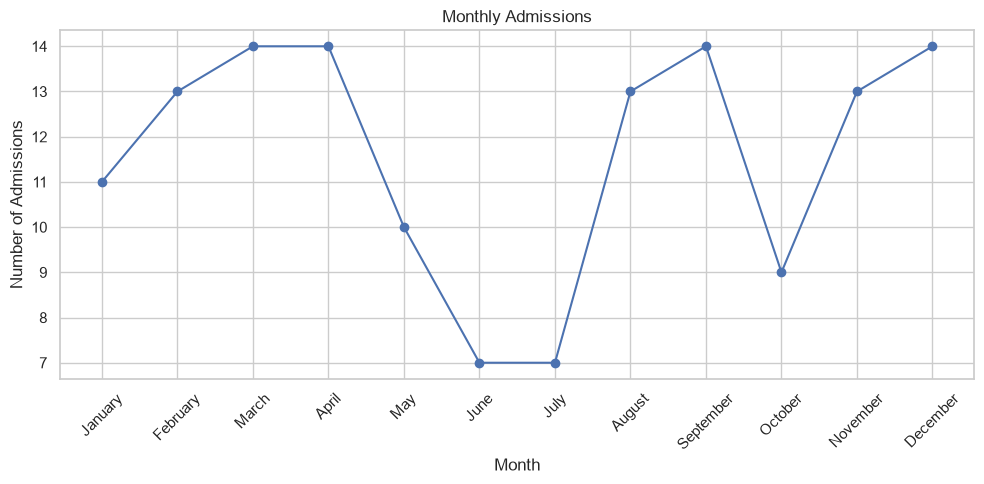

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    marker="o"
)

plt.title("Monthly Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> Seaborn

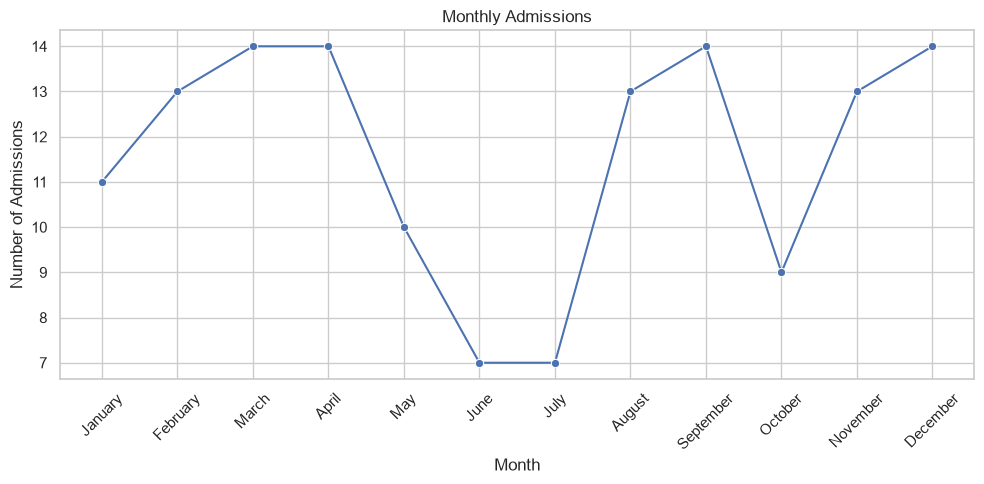

In [5]:
monthly_admissions_df = monthly_admissions.reset_index()

monthly_admissions_df.columns = ["month", "admissions"]

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_admissions_df,
    x="month",
    y="admissions",
    marker="o"
)

plt.title("Monthly Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Matplotlib vs Seaborn**

> **Matplotlib `plot()` uses the x and y values directly, while Seaborn `lineplot()` can work directly with DataFrame columns.**

#### **4 Bar Chart**

##### **What is a Bar Chart?**

A **bar chart** compares values across different categories.

Each category is represented by a bar, and the height or length of the bar represents its value.

##### **When should we use a Bar Chart?**

Bar charts are useful for comparing:

- departments
- genders
- product categories
- regions
- groups
- other categorical variables

For example, we can use a bar chart to compare the number of students in each department.

##### **Key Idea**

```text
Categories → Comparison

> Matplotlib

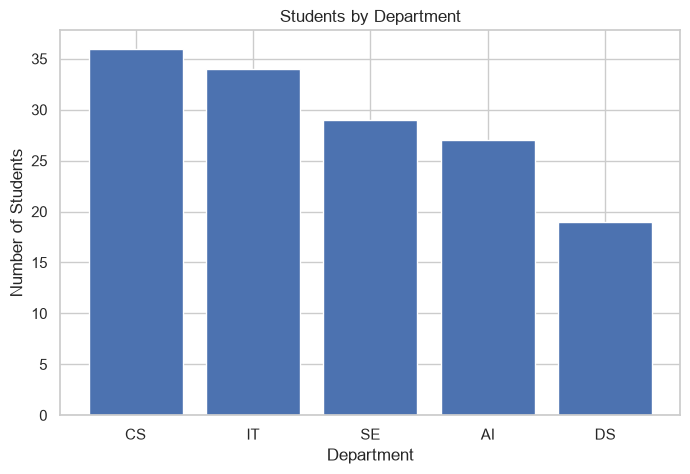

In [6]:
# Create a Bar Chart

department_counts = df["department"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(department_counts.index,
        department_counts.values)

plt.title("Students by Department")
plt.xlabel("Department")
plt.ylabel("Number of Students")

plt.show()

> Seaborn

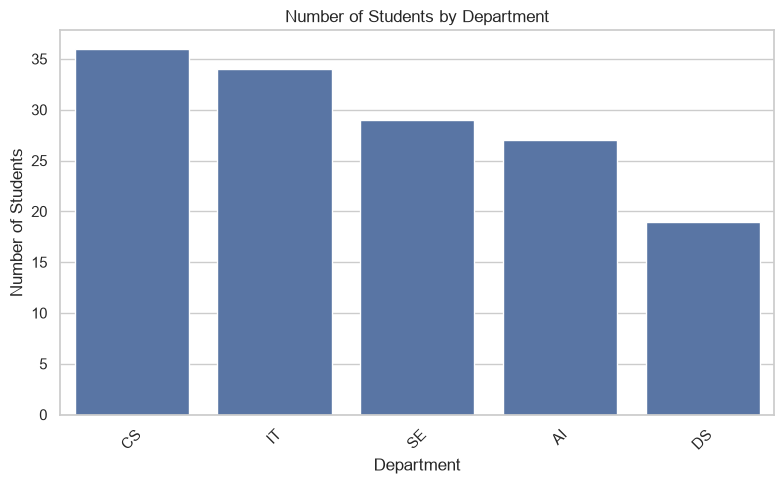

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="department",
    order=df["department"].value_counts().index
)

plt.title("Number of Students by Department")
plt.xlabel("Department")
plt.ylabel("Number of Students")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Matplotlib vs Seaborn**

> **Matplotlib `bar()` requires us to calculate and provide the category values ourselves, while Seaborn `countplot()` automatically counts the observations in each category.**

#### **5 Histogram**
##### **What is a Histogram?**

A **histogram** shows how numerical values are distributed across intervals called **bins**.

It helps us see where observations are concentrated and how values are spread.

##### **When should we use a Histogram?**

Use a histogram for numerical variables such as:

- Marks
- Age
- Attendance Percentage
- Tuition Fee
- Salary
- Height

##### **Key Idea**

```text
Numerical Variable → Distribution

> Matplotlib

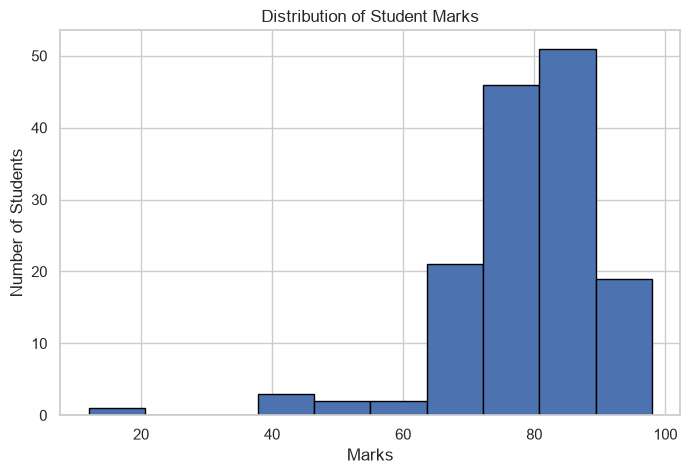

In [8]:
# Create a Histogram

plt.figure(figsize=(8,5))

plt.hist(df["marks"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Student Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")

plt.show()

> Seaborn

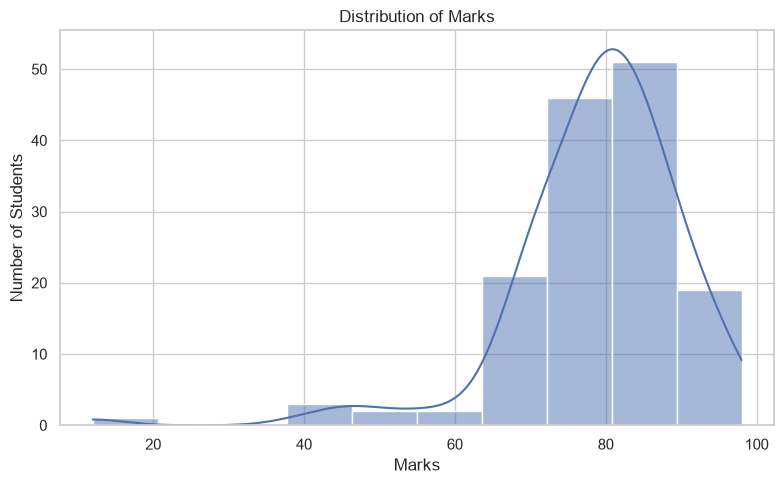

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="marks",
    bins=10,
    kde=True
)

plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

##### **Matplotlib vs Seaborn**

> **Matplotlib `hist()` works directly with numerical values, while Seaborn `histplot()` provides a DataFrame-oriented interface and additional statistical options.**

#### **6 Scatter Plot**

##### **What is a Scatter Plot?**

A **scatter plot** displays individual observations as points on a graph using two numerical variables.

It is mainly used to visualize a possible relationship between two numerical variables.

##### **When should we use a Scatter Plot?**

Use a scatter plot when you want to examine:

- Age vs Marks
- Attendance vs Marks
- Height vs Weight
- Price vs Sales

##### **Key Idea**

```text
Two Numerical Variables → Possible Relationship

> Matplotlib

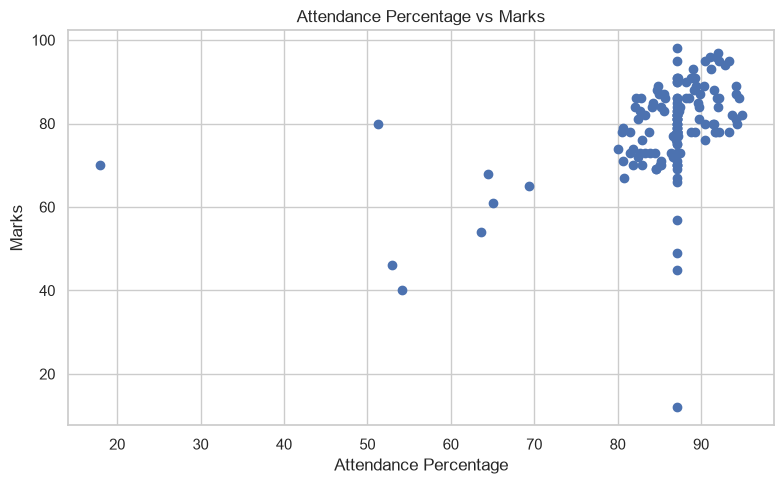

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["attendance_percentage"],
    df["marks"]
)

plt.title("Attendance Percentage vs Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Marks")

plt.tight_layout()
plt.show()

> Seaborn

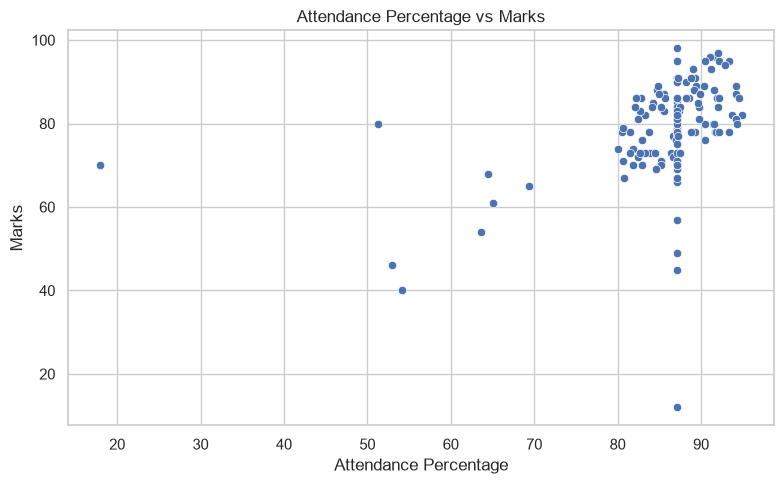

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="marks"
)

plt.title("Attendance Percentage vs Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Marks")

plt.tight_layout()
plt.show()

##### **Adding Groups with `hue`**

Seaborn allows us to use the `hue` parameter to represent a categorical variable using different visual groups.

Here, `gender` is used to distinguish observations by category.

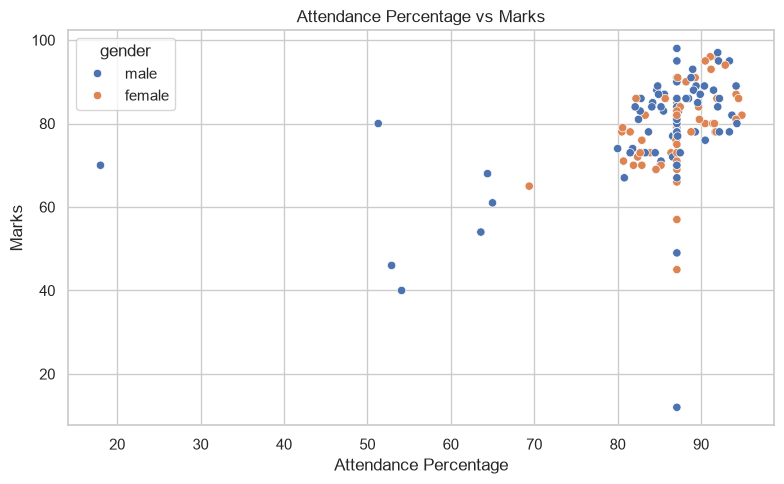

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="marks",
    hue="gender"
)
plt.title("Attendance Percentage vs Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Marks")

plt.tight_layout()
plt.show()

##### **Matplotlib vs Seaborn**

> **Matplotlib `scatter()` receives x and y values directly, while Seaborn `scatterplot()` can reference DataFrame columns and easily add grouping such as `hue`.**

#### **7 Box Plot**

##### **What is a Box Plot?**

A **box plot** summarizes the distribution of a numerical variable using:

- median
- quartiles
- spread
- possible outliers

##### **When should we use a Box Plot?**

A box plot is useful when we want to:

- compare distributions
- understand spread
- identify possible outliers

##### **Key Idea**

```text
Numerical Variable → Spread + Possible Outliers

> Matplotlib

C:\Users\ARSLAN KING\AppData\Local\Temp\ipykernel_19656\93863699.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


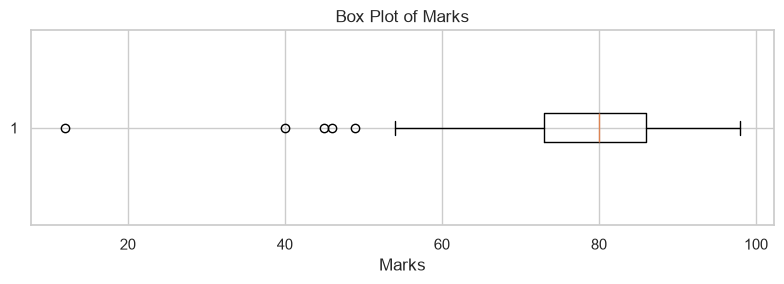

In [13]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    df["marks"],
    vert=False
)

plt.title("Box Plot of Marks")
plt.xlabel("Marks")

plt.tight_layout()
plt.show()

> Seaborn

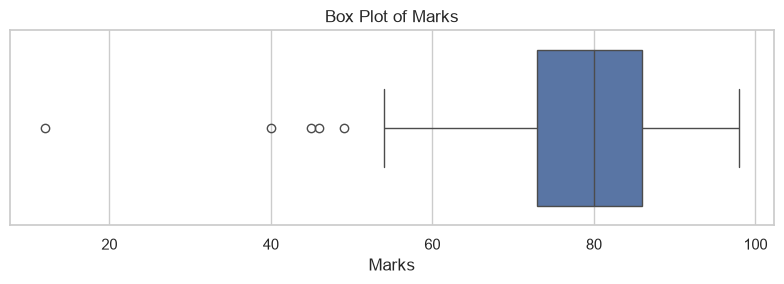

In [14]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    data=df,
    x="marks",
    orient="h"
)

plt.title("Box Plot of Marks")
plt.xlabel("Marks")

plt.tight_layout()
plt.show()

##### **Matplotlib vs Seaborn**

> **Matplotlib `boxplot()` works directly with numerical data, while Seaborn `boxplot()` works naturally with DataFrame columns and makes grouped comparisons easier.**

#### **8 Pie Chart**

##### **What is a Pie Chart?**

A **pie chart** shows how a total is divided among categories.

Each slice represents a category's share of the whole.

##### **When should we use a Pie Chart?**

Pie charts are most suitable when:

- there are only a few categories
- the categories represent parts of one whole
- showing proportions is more important than precise comparison

##### **Key Idea**

```text
Categories → Parts of a Whole

> Matplotlib

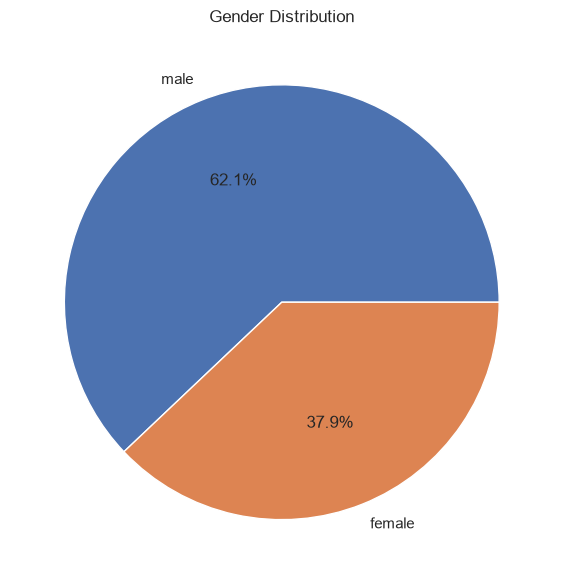

In [15]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.tight_layout()
plt.show()

> Seaborn

Seaborn does not provide a dedicated pie-chart function.

Therefore, pie charts are normally created using Matplotlib's `plt.pie()`.

##### **Matplotlib vs Seaborn**

> **Matplotlib provides `pie()`, while Seaborn does not provide a dedicated pie-chart function.**

#### **9 Heatmap**

##### **What is a Heatmap?**

A heatmap represents numerical values using different shades of color.

It is commonly used to visualize a correlation matrix.

##### **When should we use it?**

Use a heatmap when a table of numbers is difficult to compare visually.

For example, we can visualize correlations among:

- Age
- Semester
- Marks
- Attendance Percentage
- Tuition Fee

##### **Key Idea**

Numerical Matrix → Color → Easier Visual Comparison

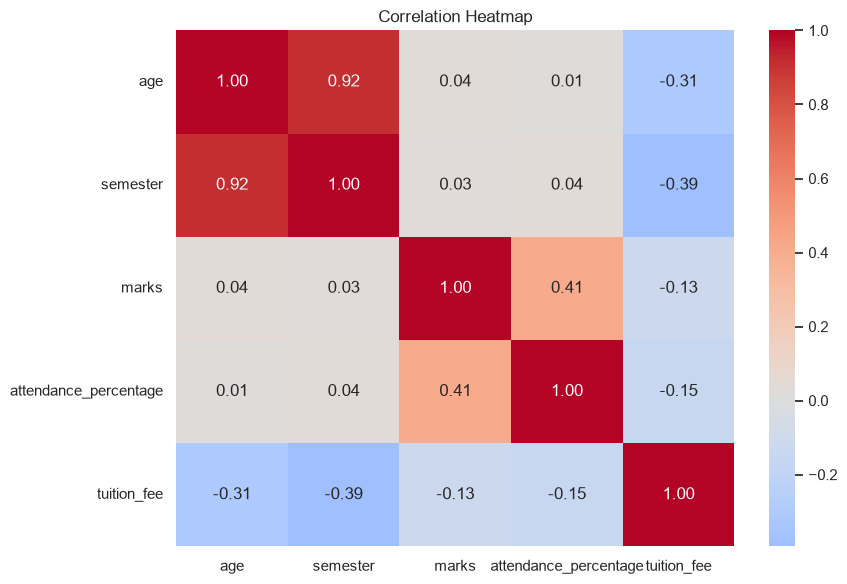

In [16]:
numerical_features = [
    "age",
    "semester",
    "marks",
    "attendance_percentage",
    "tuition_fee"
]

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### **10 Pair Plot**

##### **What is a Pair Plot?**

A pair plot creates multiple plots to show the relationships and distributions among several numerical variables.

Instead of creating many scatter plots separately, a pair plot provides a compact overview.

##### **When should we use it?**

Use a pair plot when you want a quick visual exploration of several numerical variables.

For example:

- Marks
- Age
- Attendance Percentage
- Tuition Fee

##### **Key Idea**

Multiple Numerical Variables → Multiple Pairwise Relationships

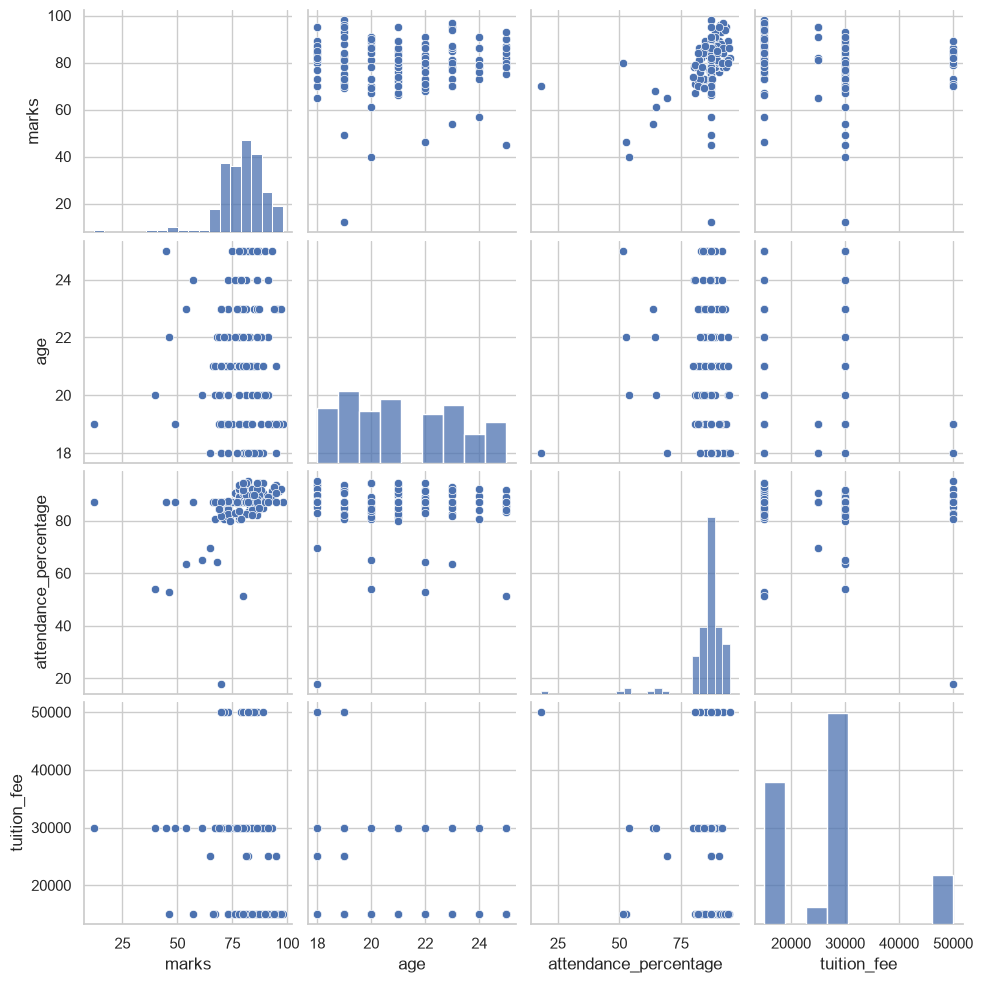

In [17]:
pairplot_features = [
    "marks",
    "age",
    "attendance_percentage",
    "tuition_fee"
]

sns.pairplot(
    df[pairplot_features]
)

plt.show()

## Summary

In this notebook, we learned how to create various charts using Matplotlib and Seaborn.

The charts covered include:

- Line Plot
- Bar Chart
- Histogram
- Scatter Plot
- Box Plot
- Pie Chart
- Count Plot
- Histplot
- Scatterplot
- Boxplot
- Heatmap
- Pairplot

These visualizations will be used in the next notebook to perform Exploratory Data Analysis (EDA) and Relationship Analysis for Machine Learning.